In [29]:
import pandas as pd

In [30]:
df = pd.read_parquet(r'C:\Users\ASUS\Downloads\finallabeled_.parquet')

In [31]:
# Replace missing values
for column in df.columns:
    if df[column].dtype in ['int64', 'float64']:  # Numerical columns
        df[column].fillna(df[column].quantile(0.75), inplace=True)
    elif df[column].dtype == 'string' or df[column].dtype == 'object':  # Categorical columns
        df[column].fillna(df[column].mode()[0], inplace=True)

C:\Users\ASUS\AppData\Local\Temp\ipykernel_7872\318582866.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[column].fillna(df[column].quantile(0.75), inplace=True)
C:\Users\ASUS\AppData\Local\Temp\ipykernel_7872\318582866.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For

In [32]:
# Display columns with their null values count
null_values = df.isnull().sum()
print(null_values)

key_ninos                                             0
primary_key                                           0
Departamento                                          0
Sexo al nacer                                         0
Edad en años cumplidos                                0
                                                     ..
Tipo de energía o combustible usado para cocinar      0
Tipo de ocupación de la vivienda                      0
Valor estimado de arriendo si se tuviera que pagar    0
Total de personas en el hogar                         0
trabajo_infantil                                      0
Length: 64, dtype: int64


In [33]:
df_trabajo = df.copy()

In [34]:
df = df.drop(columns=['trabajo_infantil'])

In [35]:
copy_df = df.copy()

In [ ]:
df

In [37]:
df.columns

Index(['key_ninos', 'primary_key', 'Departamento', 'Sexo al nacer',
       'Edad en años cumplidos', 'Parentesco con el jefe(a) del hogar',
       '¿Madre reside en el hogar?', '¿Padre reside en el hogar?',
       '¿Se considera campesino(a)?', '¿Alguna vez fue campesino(a)?',
       '¿Su comunidad es campesina?', 'Autoidentificación étnica',
       'Estado civil', '¿Cónyuge reside en el hogar?',
       'COVID: estuvo enfermo(a)', 'COVID: dificultad con alimentos/productos',
       'COVID: dificultad con pagos/deudas', 'COVID: reducción de ingresos',
       'COVID: sin trabajo o sin poder buscarlo',
       'COVID: suspensión contrato sin paga',
       'COVID: pérdida de trabajo o ingresos', 'COVID: suspensión de clases',
       'COVID: malestar emocional', 'COVID: otra dificultad',
       'COVID: sin dificultades', 'Afiliación sistema de salud',
       'Régimen de salud', 'Dificultad auditiva', 'Dificultad para hablar',
       'Dificultad visual', 'Dificultad motriz', 'Dificultad en ma

In [38]:
df.columns = (
    df.columns
    .str.strip()
    .str.replace('\n', '_')             # Reemplaza saltos de línea por espacios
    .str.replace(r'\(a\)', 'a', regex=True)  # Opcional: limpia paréntesis si están mal
    .str.replace(r'\s+', '_', regex=True)    # Reduce múltiples espacios a uno solo
)


In [39]:
# Limpiar los datos dentro de las columnas
df = df.applymap(lambda x: str(x).strip().replace(" ", "_").replace("¿", "").replace("?", "").replace(":", "").replace(",", "").replace("(", "").replace(")", "").replace("/", "_") if isinstance(x, str) else x)

# Mostrar el DataFrame limpio
print(df)

C:\Users\ASUS\AppData\Local\Temp\ipykernel_7872\228302889.py:2: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df = df.applymap(lambda x: str(x).strip().replace(" ", "_").replace("¿", "").replace("?", "").replace(":", "").replace(",", "").replace("(", "").replace(")", "").replace("/", "_") if isinstance(x, str) else x)


        key_ninos  primary_key     Departamento Sexo_al_nacer  \
0       730906013     73090601     Cundinamarca         Mujer   
1       730906414     73090641        Risaralda         Mujer   
2       730906812     73090681        Risaralda         Mujer   
3       730906913     73090691        Risaralda        Hombre   
4       730907013     73090701        Risaralda         Mujer   
...           ...          ...              ...           ...   
176343  756731615     75673161  Valle_del_Cauca         Mujer   
176344  756731814     75673181           Caldas        Hombre   
176345  756731815     75673181           Caldas         Mujer   
176346  756731913     75673191        Antioquia        Hombre   
176347  756732313     75673231  Valle_del_Cauca        Hombre   

        Edad_en_años_cumplidos Parentesco_con_el_jefea_del_hogar  \
0                            7                   Hijoa_hijastroa   
1                           13                   Hijoa_hijastroa   
2              

In [40]:
df = df.drop(columns=['key_ninos', 'primary_key'])

In [41]:
# Identificar columnas categóricas
categorical_cols = df.select_dtypes(include=['object', 'category']).columns

# Diccionario para almacenar los mapeos de categorías
label_maps = {}

# Aplicar label encoding y guardar los mapeos
for col in categorical_cols:
    df[col] = df[col].astype('category', 'object')
    label_maps[col] = dict(enumerate(df[col].cat.categories))
    df[col] = df[col].cat.codes

# Mostrar el DataFrame codificado
print(df)

# Mostrar los mapeos
print("\nMapeos de categorías:")
for col, mapping in label_maps.items():
    print(f"{col}: {mapping}")

        Departamento  Sexo_al_nacer  Edad_en_años_cumplidos  \
0                 14              1                       7   
1                 26              1                      13   
2                 26              1                      17   
3                 26              0                      13   
4                 26              1                      17   
...              ...            ...                     ...   
176343            30              1                       5   
176344             8              0                      16   
176345             8              1                       9   
176346             1              0                      10   
176347            30              0                       9   

        Parentesco_con_el_jefea_del_hogar  ¿Madre_reside_en_el_hogar?  \
0                                       2                           2   
1                                       2                           2   
2                       

In [42]:
# Convertir las variables categóricas a int64
categorical_cols = df.select_dtypes(include=['object', 'category']).columns
df[categorical_cols] = df[categorical_cols].astype('int64')

# Verificar los cambios
print(df.dtypes)

Departamento                                             int8
Sexo_al_nacer                                            int8
Edad_en_años_cumplidos                                  int64
Parentesco_con_el_jefea_del_hogar                        int8
¿Madre_reside_en_el_hogar?                               int8
                                                       ...   
Lugar_donde_se_preparan_los_alimentos                    int8
Tipo_de_energía_o_combustible_usado_para_cocinar         int8
Tipo_de_ocupación_de_la_vivienda                         int8
Valor_estimado_de_arriendo_si_se_tuviera_que_pagar    float64
Total_de_personas_en_el_hogar                         float64
Length: 61, dtype: object


In [43]:
from sklearn.preprocessing import StandardScaler

# Initialize the scaler
scaler = StandardScaler()

# Select numerical columns for standardization
numerical_columns = df.select_dtypes(include=['int64', 'float64','int8']).columns

# Apply standardization
df[numerical_columns] = scaler.fit_transform(df[numerical_columns])

In [14]:
df

,Departamento,Sexo_al_nacer,Edad_en_años_cumplidos,Parentesco_con_el_jefea_del_hogar,¿Madre_reside_en_el_hogar?,¿Padre_reside_en_el_hogar?,¿Se_considera_campesinoa?,¿Alguna_vez_fue_campesinoa?,¿Su_comunidad_es_campesina?,Autoidentificación_étnica,...,Número_de_cuartos_usados_para_dormir,Tipo_de_servicio_sanitario_que_utiliza_el_hogar,Forma_de_disposición_del_servicio_sanitario,Método_de_eliminación_de_basuras_en_el_hogar,Fuente_principal_de_agua_para_consumo_humano,Lugar_donde_se_preparan_los_alimentos,Tipo_de_energía_o_combustible_usado_para_cocinar,Tipo_de_ocupación_de_la_vivienda,Valor_estimado_de_arriendo_si_se_tuviera_que_pagar,Total_de_personas_en_el_hogar
0,-0.248470,1.021449,-1.116687,-0.499811,0.398933,-0.795657,1.959271,-0.078863,-0.496421,0.379189,...,-0.420021,-0.446996,0.142796,0.345248,0.006170,-0.451025,0.973052,-0.816493,0.000000,-0.907843
1,1.096032,1.021449,0.492447,-0.499811,0.398933,1.006294,1.959271,-0.078863,2.014418,0.379189,...,0.819936,0.761634,0.142796,0.345248,0.006170,-0.451025,-0.543347,-0.816493,0.000000,0.281332
2,1.096032,1.021449,1.565202,-0.499811,0.398933,-0.795657,1.959271,-0.078863,2.014418,0.379189,...,-1.659978,0.761634,0.142796,0.345248,0.006170,-0.451025,-0.543347,-0.355075,-0.058530,-1.502431
3,1.096032,-0.979001,0.492447,2.150382,0.398933,-0.795657,-0.510394,-0.078863,-0.496421,0.379189,...,-0.420021,0.761634,0.142796,0.345248,0.006170,2.243999,-0.543347,1.490597,-0.101703,0.281332
4,1.096032,1.021449,1.565202,-0.499811,0.398933,1.006294,1.959271,-0.078863,2.014418,0.379189,...,-1.659978,0.761634,0.142796,0.345248,0.006170,-0.451025,-0.543347,-0.816493,0.000000,0.281332
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
176343,1.544199,1.021449,-1.653064,2.150382,0.398933,1.006294,-0.510394,-0.078863,-0.496421,0.379189,...,0.819936,-0.446996,0.142796,0.345248,0.006170,-0.451025,-0.543347,1.490597,-0.134062,0.281332
176344,-0.920721,-0.979001,1.297013,-0.499811,0.398933,-0.795657,1.959271,-0.078863,2.014418,0.379189,...,2.059893,1.970264,0.142796,0.345248,0.769199,-0.451025,0.973052,1.490597,-0.026150,1.470508
176345,-0.920721,1.021449,-0.580309,-0.499811,0.398933,-0.795657,1.959271,-0.078863,2.014418,0.379189,...,2.059893,1.970264,0.142796,0.345248,0.769199,-0.451025,0.973052,1.490597,-0.026150,1.470508
176346,-1.705014,-0.979001,-0.312120,-0.499811,0.398933,1.006294,1.959271,-0.078863,-0.496421,0.379189,...,0.819936,-0.446996,0.142796,0.345248,0.006170,-0.451025,-0.543347,-0.816493,0.000000,-0.907843


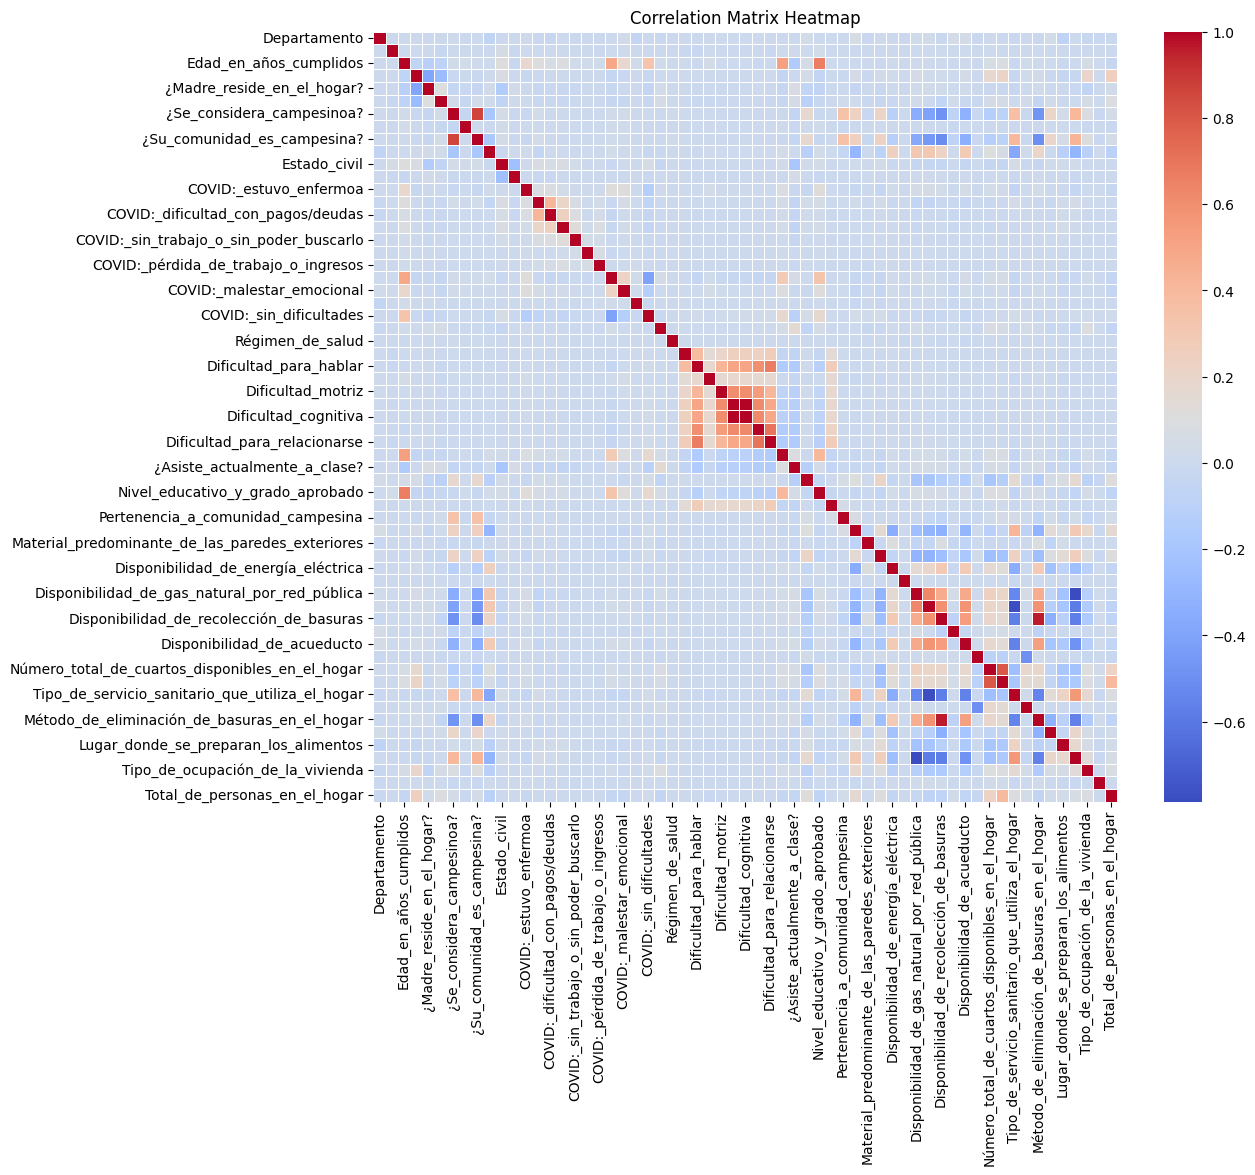

In [44]:
import seaborn as sns

import matplotlib.pyplot as plt

# Compute the correlation matrix
correlation_matrix = df.corr()

# Plot the heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix Heatmap')
plt.show()

In [45]:
df['trabajo_infantil'] = df_trabajo['trabajo_infantil']

In [46]:
df

,Departamento,Sexo_al_nacer,Edad_en_años_cumplidos,Parentesco_con_el_jefea_del_hogar,¿Madre_reside_en_el_hogar?,¿Padre_reside_en_el_hogar?,¿Se_considera_campesinoa?,¿Alguna_vez_fue_campesinoa?,¿Su_comunidad_es_campesina?,Autoidentificación_étnica,...,Tipo_de_servicio_sanitario_que_utiliza_el_hogar,Forma_de_disposición_del_servicio_sanitario,Método_de_eliminación_de_basuras_en_el_hogar,Fuente_principal_de_agua_para_consumo_humano,Lugar_donde_se_preparan_los_alimentos,Tipo_de_energía_o_combustible_usado_para_cocinar,Tipo_de_ocupación_de_la_vivienda,Valor_estimado_de_arriendo_si_se_tuviera_que_pagar,Total_de_personas_en_el_hogar,trabajo_infantil
0,-0.248470,1.021449,-1.116687,-0.499811,0.398933,-0.795657,1.959271,-0.078863,-0.496421,0.379189,...,-0.446996,0.142796,0.345248,0.006170,-0.451025,0.973052,-0.816493,0.000000,-0.907843,True
1,1.096032,1.021449,0.492447,-0.499811,0.398933,1.006294,1.959271,-0.078863,2.014418,0.379189,...,0.761634,0.142796,0.345248,0.006170,-0.451025,-0.543347,-0.816493,0.000000,0.281332,True
2,1.096032,1.021449,1.565202,-0.499811,0.398933,-0.795657,1.959271,-0.078863,2.014418,0.379189,...,0.761634,0.142796,0.345248,0.006170,-0.451025,-0.543347,-0.355075,-0.058530,-1.502431,True
3,1.096032,-0.979001,0.492447,2.150382,0.398933,-0.795657,-0.510394,-0.078863,-0.496421,0.379189,...,0.761634,0.142796,0.345248,0.006170,2.243999,-0.543347,1.490597,-0.101703,0.281332,True
4,1.096032,1.021449,1.565202,-0.499811,0.398933,1.006294,1.959271,-0.078863,2.014418,0.379189,...,0.761634,0.142796,0.345248,0.006170,-0.451025,-0.543347,-0.816493,0.000000,0.281332,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
176343,1.544199,1.021449,-1.653064,2.150382,0.398933,1.006294,-0.510394,-0.078863,-0.496421,0.379189,...,-0.446996,0.142796,0.345248,0.006170,-0.451025,-0.543347,1.490597,-0.134062,0.281332,True
176344,-0.920721,-0.979001,1.297013,-0.499811,0.398933,-0.795657,1.959271,-0.078863,2.014418,0.379189,...,1.970264,0.142796,0.345248,0.769199,-0.451025,0.973052,1.490597,-0.026150,1.470508,True
176345,-0.920721,1.021449,-0.580309,-0.499811,0.398933,-0.795657,1.959271,-0.078863,2.014418,0.379189,...,1.970264,0.142796,0.345248,0.769199,-0.451025,0.973052,1.490597,-0.026150,1.470508,True
176346,-1.705014,-0.979001,-0.312120,-0.499811,0.398933,1.006294,1.959271,-0.078863,-0.496421,0.379189,...,-0.446996,0.142796,0.345248,0.006170,-0.451025,-0.543347,-0.816493,0.000000,-0.907843,True


In [47]:
# Identificar pares de variables con alta correlación
threshold = 0.8  # Umbral de correlación
correlation_matrix = df.corr()

# Filtrar pares de variables con correlación mayor al umbral
high_correlation_pairs = correlation_matrix.stack().loc[lambda x: (x >= threshold) & (x < 1)]

# Mostrar las variables altamente correlacionadas
print(high_correlation_pairs)

¿Se_considera_campesinoa?                        ¿Su_comunidad_es_campesina?                        0.862423
¿Su_comunidad_es_campesina?                      ¿Se_considera_campesinoa?                          0.862423
Disponibilidad_de_recolección_de_basuras         Método_de_eliminación_de_basuras_en_el_hogar       0.962559
Número_total_de_cuartos_disponibles_en_el_hogar  Número_de_cuartos_usados_para_dormir               0.802776
Número_de_cuartos_usados_para_dormir             Número_total_de_cuartos_disponibles_en_el_hogar    0.802776
Método_de_eliminación_de_basuras_en_el_hogar     Disponibilidad_de_recolección_de_basuras           0.962559
dtype: float64


In [48]:
# Eliminar variables correlacionadas
correlated_variables = high_correlation_pairs.index.get_level_values(0).unique()
df = df.drop(columns=correlated_variables)

# Mostrar las columnas restantes
print(df.columns)

Index(['Departamento', 'Sexo_al_nacer', 'Edad_en_años_cumplidos',
       'Parentesco_con_el_jefea_del_hogar', '¿Madre_reside_en_el_hogar?',
       '¿Padre_reside_en_el_hogar?', '¿Alguna_vez_fue_campesinoa?',
       'Autoidentificación_étnica', 'Estado_civil',
       '¿Cónyuge_reside_en_el_hogar?', 'COVID:_estuvo_enfermoa',
       'COVID:_dificultad_con_alimentos/productos',
       'COVID:_dificultad_con_pagos/deudas', 'COVID:_reducción_de_ingresos',
       'COVID:_sin_trabajo_o_sin_poder_buscarlo',
       'COVID:_suspensión_contrato_sin_paga',
       'COVID:_pérdida_de_trabajo_o_ingresos', 'COVID:_suspensión_de_clases',
       'COVID:_malestar_emocional', 'COVID:_otra_dificultad',
       'COVID:_sin_dificultades', 'Afiliación_sistema_de_salud',
       'Régimen_de_salud', 'Dificultad_auditiva', 'Dificultad_para_hablar',
       'Dificultad_visual', 'Dificultad_motriz', 'Dificultad_en_manos',
       'Dificultad_cognitiva', 'Dificultad_en_autocuidado',
       'Dificultad_para_relacionarse'

In [49]:
df[['key_ninos', 'primary_key']] = copy_df[['key_ninos', 'primary_key']]

In [51]:
# Specify the columns to move to the beginning
columns_to_move = ['key_ninos', 'primary_key', 'trabajo_infantil']

# Reorder the columns
df = df[columns_to_move + [col for col in df.columns if col not in columns_to_move]]

# Display the updated DataFrame
print(df.head())

   key_ninos  primary_key  trabajo_infantil  Departamento  Sexo_al_nacer  \
0  730906013     73090601              True     -0.248470       1.021449   
1  730906414     73090641              True      1.096032       1.021449   
2  730906812     73090681              True      1.096032       1.021449   
3  730906913     73090691              True      1.096032      -0.979001   
4  730907013     73090701              True      1.096032       1.021449   

   Edad_en_años_cumplidos  Parentesco_con_el_jefea_del_hogar  \
0               -1.116687                          -0.499811   
1                0.492447                          -0.499811   
2                1.565202                          -0.499811   
3                0.492447                           2.150382   
4                1.565202                          -0.499811   

   ¿Madre_reside_en_el_hogar?  ¿Padre_reside_en_el_hogar?  \
0                    0.398933                   -0.795657   
1                    0.398933       

In [52]:
df.to_csv(r'C:\Users\ASUS\Downloads\df_para_modelo_II.csv', index=False)